In [1]:
# ============================================================
# 0. Imports & Configuration
# ============================================================

import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import signal
from scipy.fft import rfft, rfftfreq

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set(style="whitegrid")

FS = 2000
DATA_DIR = Path("/home/mamunds/job/pyspark/konux/data")


In [2]:
# ============================================================
# 1. Helper Functions
# ============================================================

def load_binary_signal(filepath):
    return np.fromfile(filepath, dtype=np.float32)

def parse_filename_metadata(filename):
    meta = {}
    m = re.match(r"(\d{8})_(\d{6})_(\d+)_", filename)
    if m:
        meta["date"], meta["time"], meta["sensor_id"] = m.groups()
    return meta

def bandpass_filter_zero_phase(x, fs, low=5, high=500, order=4):
    x = x - np.mean(x)
    b, a = signal.butter(order, [low/(fs/2), high/(fs/2)], btype="band")
    return signal.filtfilt(b, a, x)

def rms_envelope(x, fs, window_s=0.05):
    w = max(1, int(window_s * fs))
    return np.sqrt(np.convolve(x**2, np.ones(w)/w, mode="same"))

def segment_active_region(env, fs):
    baseline = env[:int(0.5*fs)]
    thr = np.mean(baseline) + 3*np.std(baseline)
    idx = np.where(env > thr)[0]
    if len(idx) == 0:
        return 0, len(env)
    return idx[0], idx[-1]

def extract_time_features(x, fs):
    peaks, _ = signal.find_peaks(np.abs(x), height=np.std(x))
    return {
        "rms": np.sqrt(np.mean(x**2)),
        "peak_to_peak": np.max(x) - np.min(x),
        "num_peaks": len(peaks),
        "mean_peak_interval_s": np.mean(np.diff(peaks))/fs if len(peaks) > 1 else np.nan
    }

def extract_frequency_features(x, fs):
    yf = np.abs(rfft(x))
    xf = rfftfreq(len(x), 1/fs)
    return {
        "spectral_centroid_hz": np.sum(xf*yf)/np.sum(yf),
        "dominant_frequency_hz": xf[np.argmax(yf)]
    }


In [3]:
# ============================================================
# 2. Load Data & Metadata
# ============================================================

signals = {}
rows = []

for fp in DATA_DIR.glob("*.bin"):
    x = load_binary_signal(fp)
    signals[fp.name] = x
    meta = parse_filename_metadata(fp.name)
    rows.append({"file": fp.name, **meta, "duration_s": len(x)/FS})

meta_df = pd.DataFrame(rows).set_index("file")
meta_df


,date,time,sensor_id,duration_s
file,,,,
20220517_122558_080808_001_channel1.bin,20220517,122558,080808,8.0
20220509_105854_095913_001_channel1.bin,20220509,105854,095913,20.0
20220511_110903_077531_001_channel1.bin,20220511,110903,077531,12.0
20220521_121352_079966_001_channel1.bin,20220521,121352,079966,8.0
20220517_120716_058309_001_channel1.bin,20220517,120716,058309,6.0
20220509_091022_031264_001_channel1.bin,20220509,091022,031264,17.0
20220507_131853_065205_001_channel1.bin,20220507,131853,065205,7.0
20220507_131544_065205_001_channel1.bin,20220507,131544,065205,8.0
20220521_121722_079966_001_channel1.bin,20220521,121722,079966,12.0


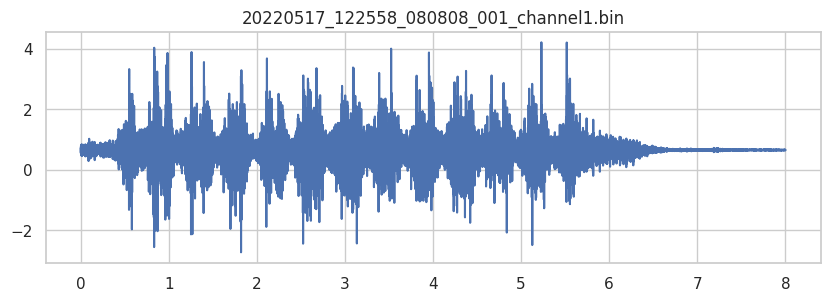

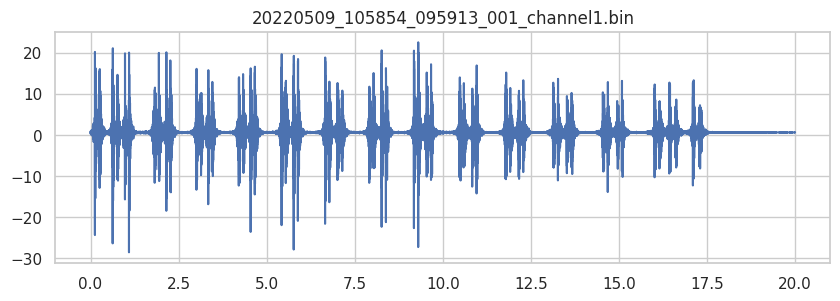

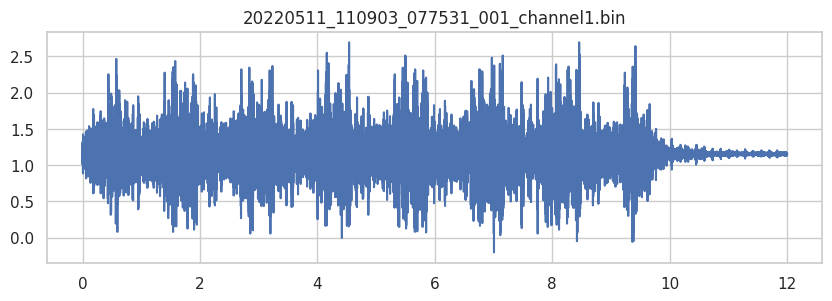

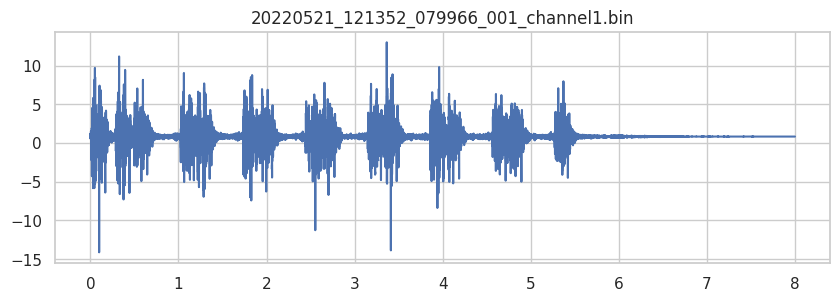

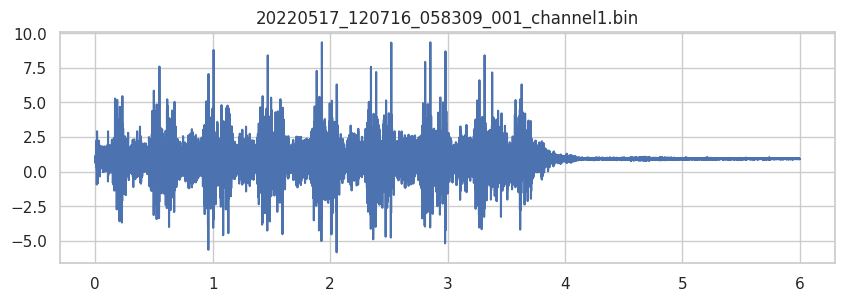

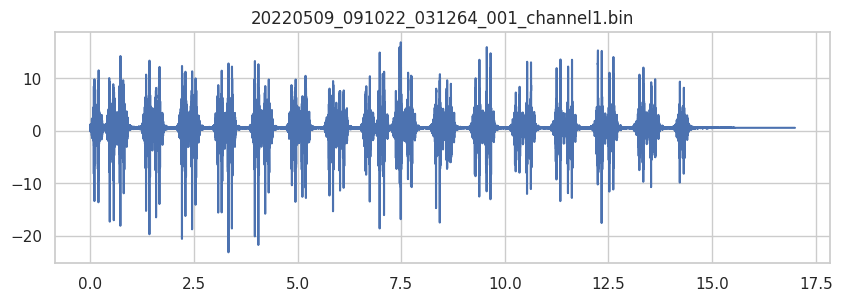

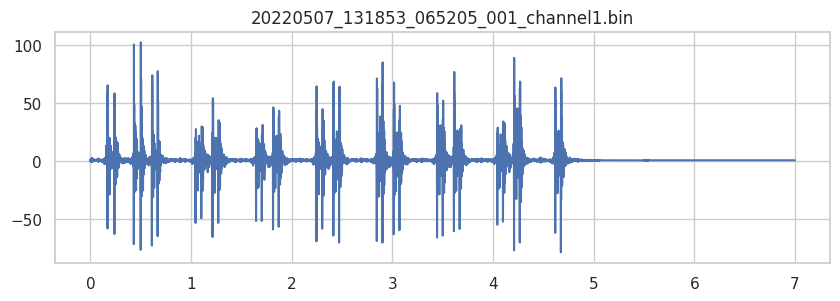

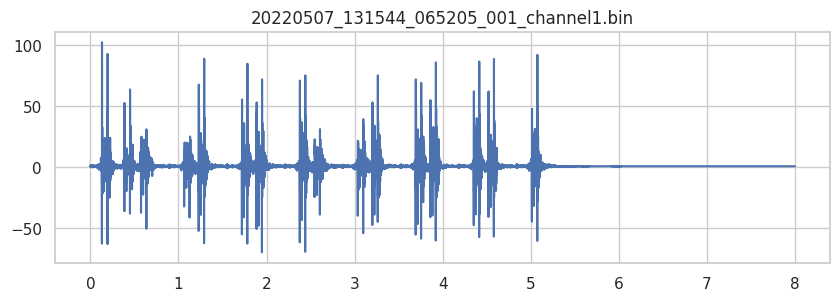

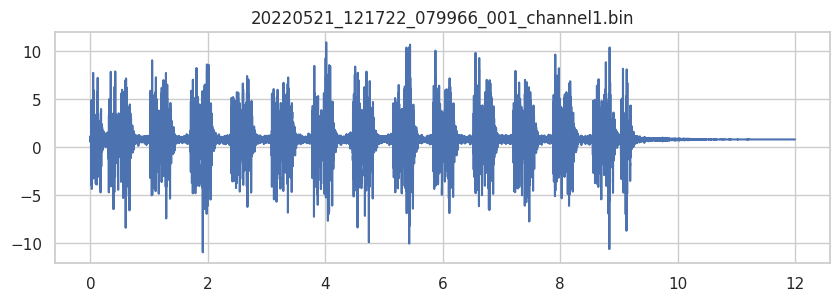

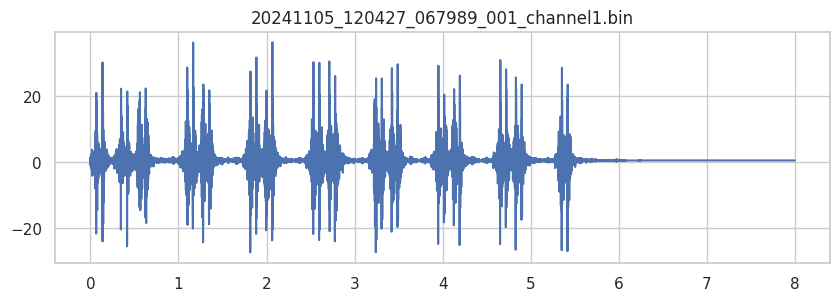

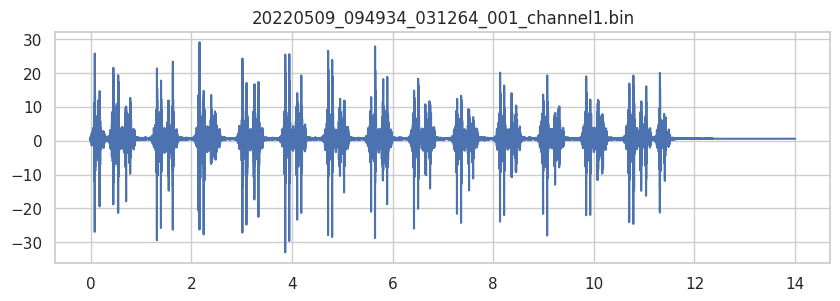

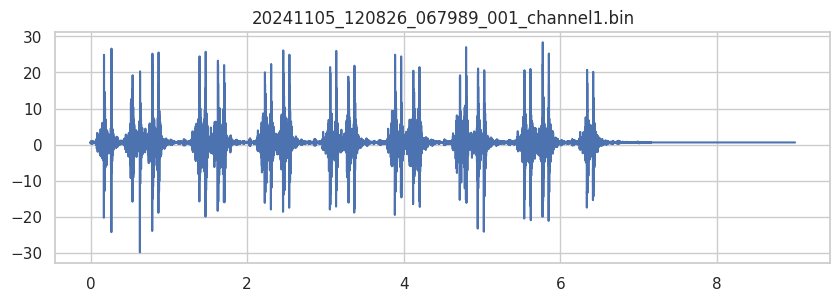

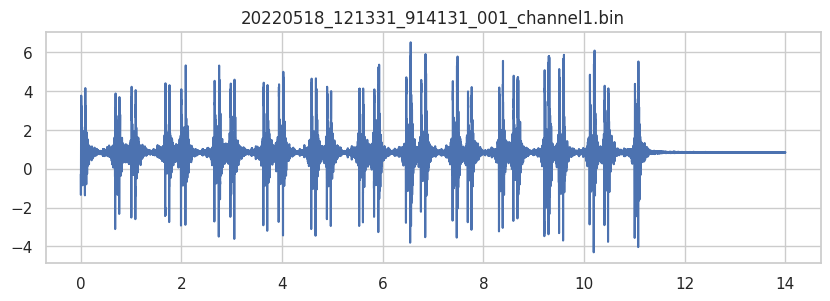

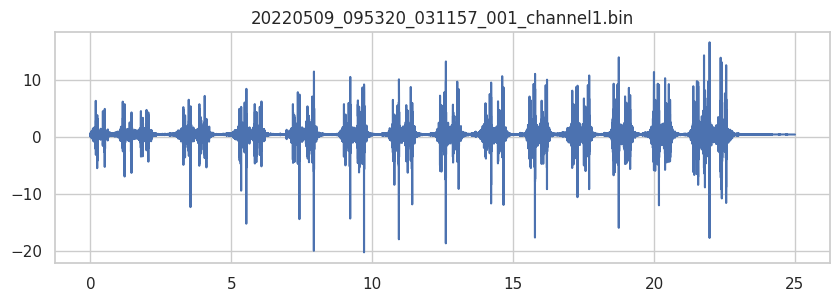

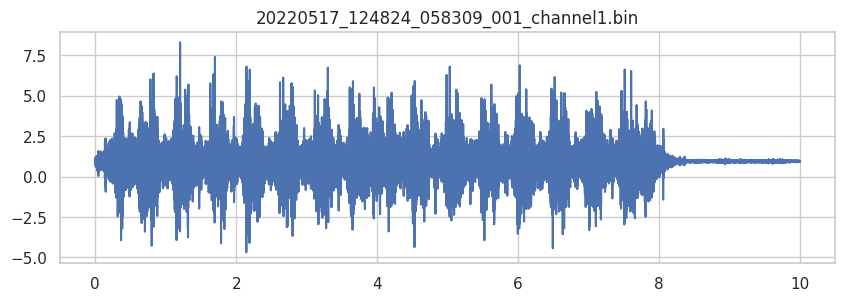

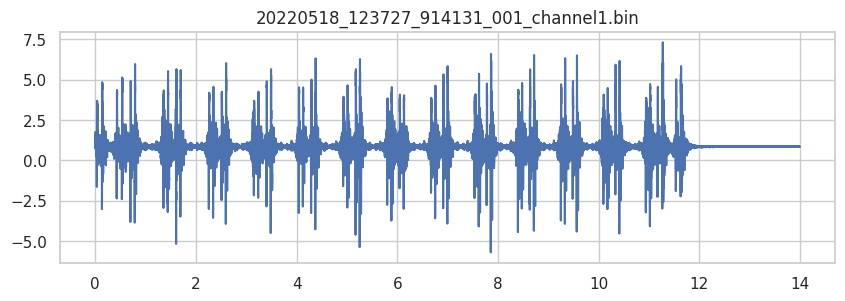

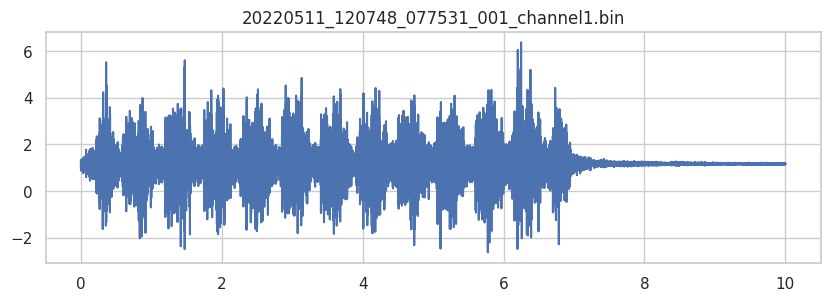

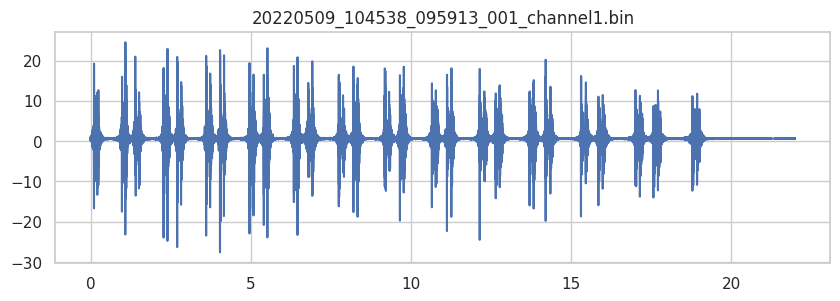

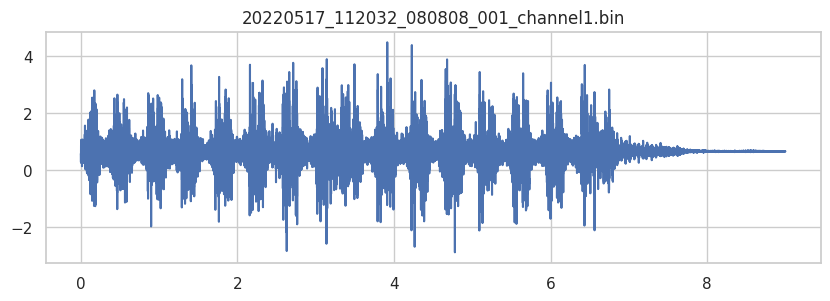

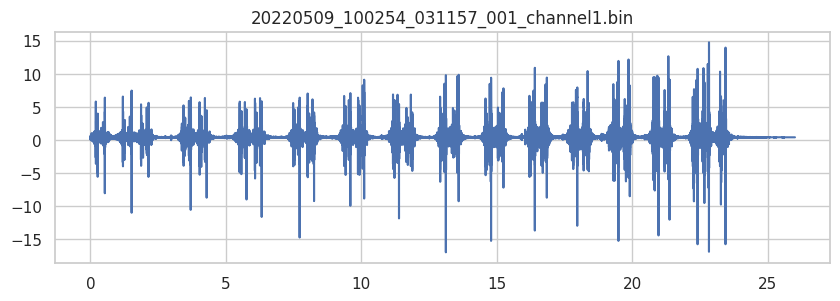

In [ ]:

v # ============================================================
# 3. Raw Signal Exploration
# ============================================================

for fname, x in signals.items():
    t = np.arange(len(x))/FS
    plt.figure(figsize=(10,3))
    plt.plot(t, x)
    plt.title(fname)
    plt.grid(True)
    plt.show()


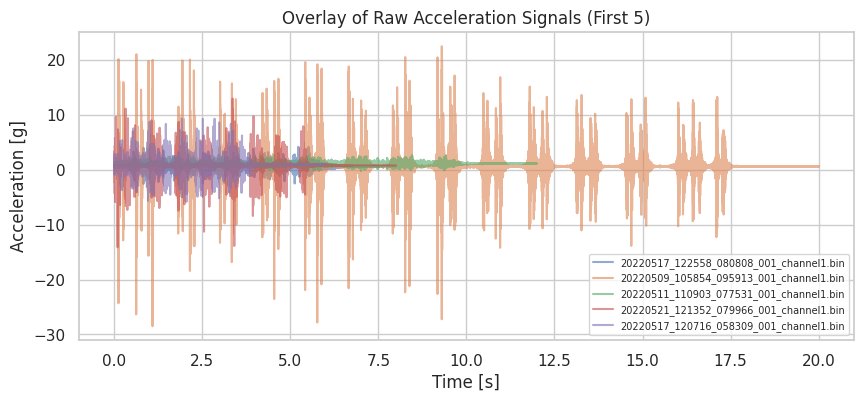

In [5]:
# Overlay of first 5 raw signals
plt.figure(figsize=(10,4))
for fname in list(signals.keys())[:5]:
    x = signals[fname]
    t = np.arange(len(x))/FS
    plt.plot(t, x, alpha=0.6, label=fname)

plt.xlabel("Time [s]")
plt.ylabel("Acceleration [g]")
plt.title("Overlay of Raw Acceleration Signals (First 5)")
plt.legend(fontsize=7)
plt.grid(True)
plt.show()


In [6]:
# ============================================================
# 4. Preprocessing & Segmentation
# ============================================================

signals_filt = {}
segments = {}

for fname, x in signals.items():
    xf = bandpass_filter_zero_phase(x, FS)
    env = rms_envelope(xf, FS)
    s, e = segment_active_region(env, FS)
    signals_filt[fname] = xf
    segments[fname] = (s, e)


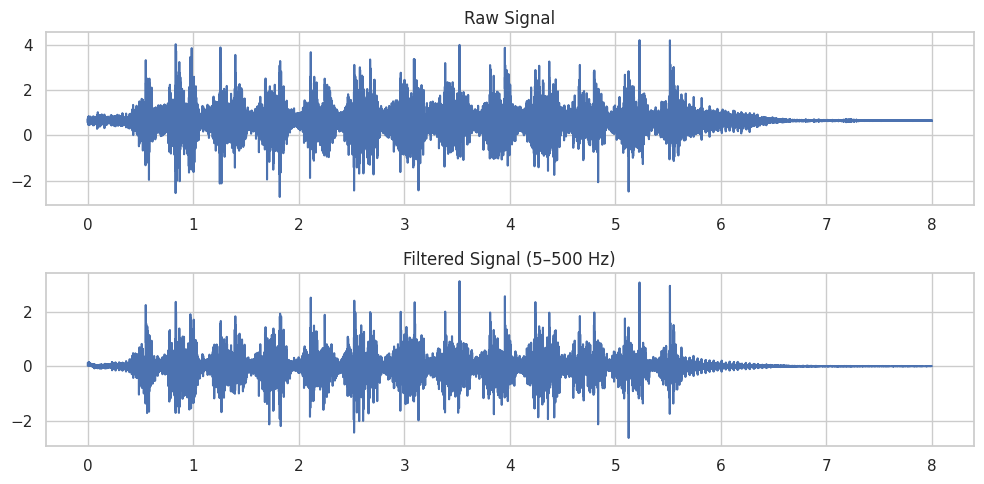

In [7]:
# Raw vs Filtered comparison
example_file = meta_df.index[0]
x_raw = signals[example_file]
x_filt = signals_filt[example_file]

n = min(len(x_raw), len(x_filt))
t = np.arange(n)/FS

plt.figure(figsize=(10,5))
plt.subplot(2,1,1)
plt.plot(t, x_raw[:n])
plt.title("Raw Signal")
plt.grid(True)

plt.subplot(2,1,2)
plt.plot(t, x_filt[:n])
plt.title("Filtered Signal (5–500 Hz)")
plt.grid(True)
plt.tight_layout()
plt.show()


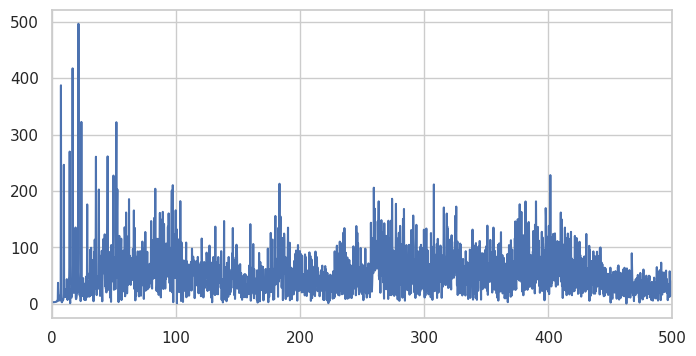

In [8]:
# ============================================================
# 5. Frequency Spectrum (FFT)
# ============================================================

fname = list(signals.keys())[0]
s, e = segments[fname]
xseg = signals_filt[fname][s:e]

yf = np.abs(rfft(xseg))
xf = rfftfreq(len(xseg), 1/FS)

plt.figure(figsize=(8,4))
plt.plot(xf, yf)
plt.xlim(0, 500)
plt.grid(True)
plt.show()


In [9]:
# ============================================================
# 6. Feature Extraction
# ============================================================

rows = []
for fname in meta_df.index:
    s, e = segments[fname]
    xseg = signals_filt[fname][s:e]

    feats = {}
    feats.update(parse_filename_metadata(fname))
    feats.update(extract_time_features(xseg, FS))
    feats.update(extract_frequency_features(xseg, FS))
    feats["active_duration_s"] = (e-s)/FS
    feats["file"] = fname
    rows.append(feats)

features_df = pd.DataFrame(rows).set_index("file")
features_df


,date,time,sensor_id,rms,peak_to_peak,num_peaks,mean_peak_interval_s,spectral_centroid_hz,dominant_frequency_hz,active_duration_s
file,,,,,,,,,,
20220517_122558_080808_001_channel1.bin,20220517,122558,080808,0.471155,5.744728,1167,0.004371,267.979824,21.174395,5.1005
20220509_105854_095913_001_channel1.bin,20220509,105854,095913,1.570273,44.038942,1716,0.010048,275.537639,153.950000,20.0000
20220511_110903_077531_001_channel1.bin,20220511,110903,077531,0.274914,2.739692,2632,0.003360,281.152262,42.849067,8.8450
20220521_121352_079966_001_channel1.bin,20220521,121352,079966,1.113906,21.922877,997,0.005470,242.206566,73.500000,8.0000
20220517_120716_058309_001_channel1.bin,20220517,120716,058309,0.986060,12.799808,375,0.006274,281.614718,93.231162,2.3490
20220509_091022_031264_001_channel1.bin,20220509,091022,031264,1.490862,33.531185,2027,0.007091,270.079287,195.058824,17.0000
20220507_131853_065205_001_channel1.bin,20220507,131853,065205,6.829386,153.924298,510,0.008943,269.302788,71.714286,7.0000
20220507_131544_065205_001_channel1.bin,20220507,131544,065205,6.119571,147.311505,583,0.008562,268.039206,65.375000,8.0000
20220521_121722_079966_001_channel1.bin,20220521,121722,079966,1.497176,18.834176,555,0.006267,254.132015,92.842771,3.4790


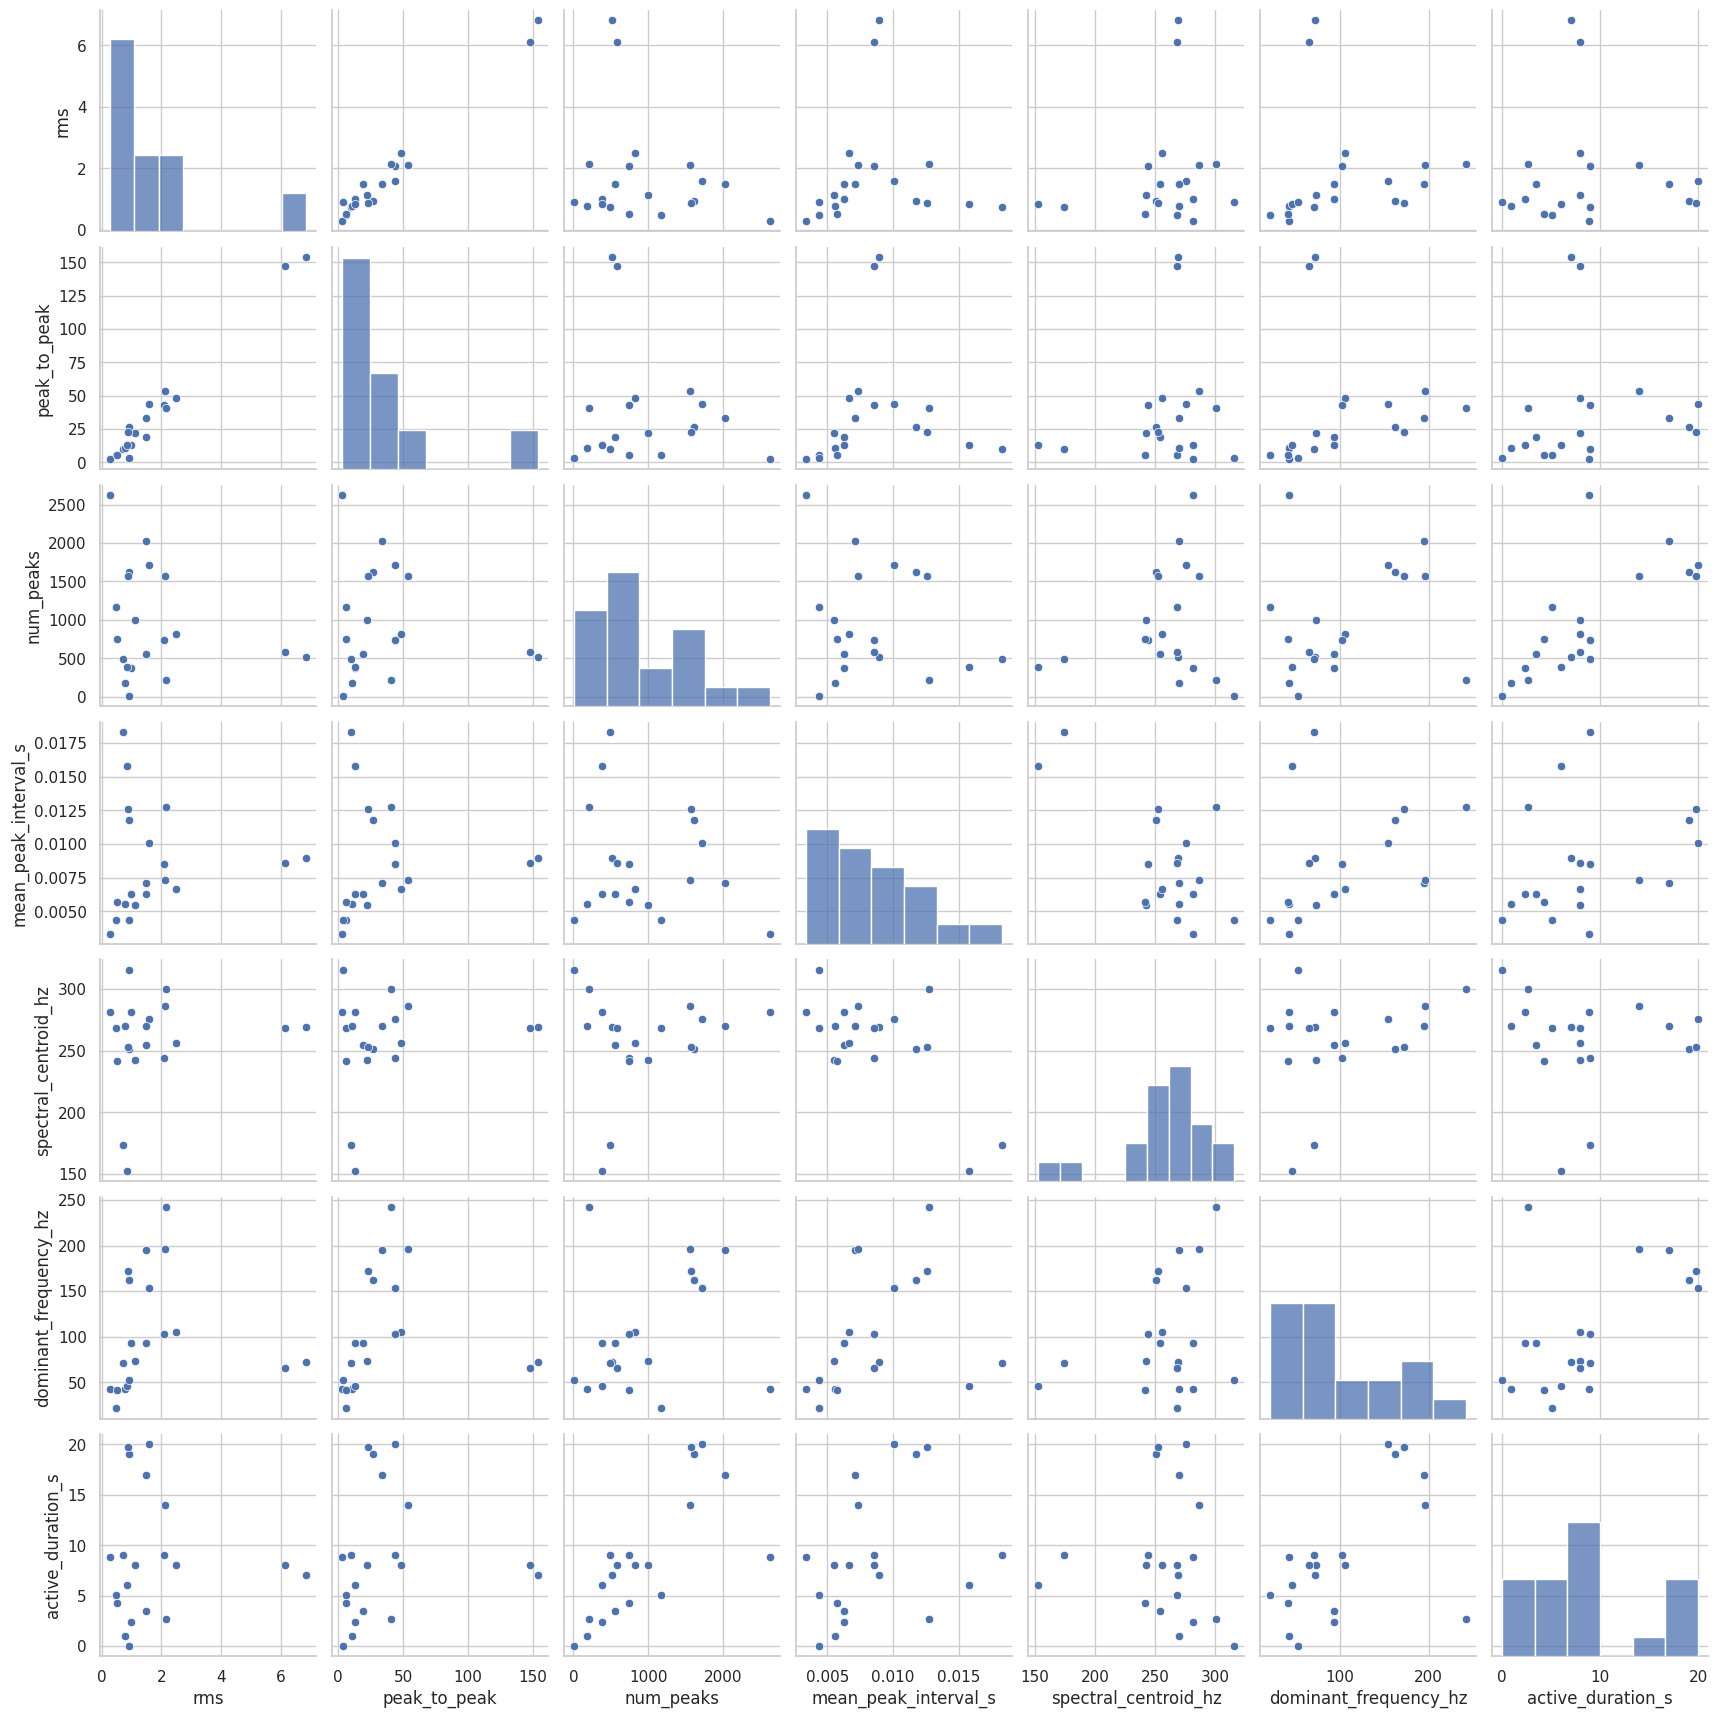

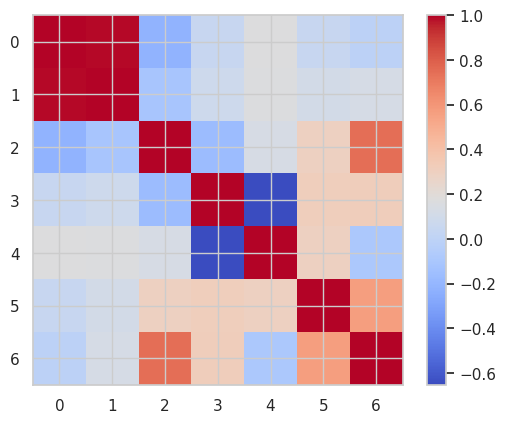

In [10]:
# ============================================================
# 7. Feature Exploration
# ============================================================

sns.pairplot(features_df.select_dtypes(np.number).dropna())
plt.show()

corr = features_df.select_dtypes(np.number).corr()
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.show()


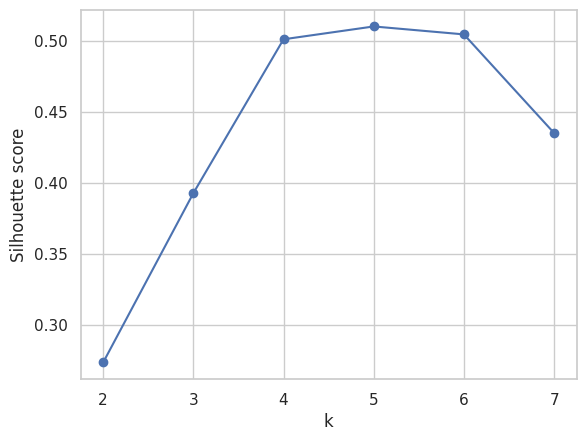

In [11]:
# ============================================================
# 8. Clustering (Silhouette + KMeans)
# ============================================================

X = features_df.select_dtypes(include=[np.number])
X = X.fillna(X.mean())
X_scaled = StandardScaler().fit_transform(X)

k_range = range(2, 8)
scores = []

for k in k_range:
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, labels))

plt.plot(k_range, scores, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.show()

best_k = k_range[np.argmax(scores)]
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
features_df["cluster"] = kmeans.fit_predict(X_scaled)


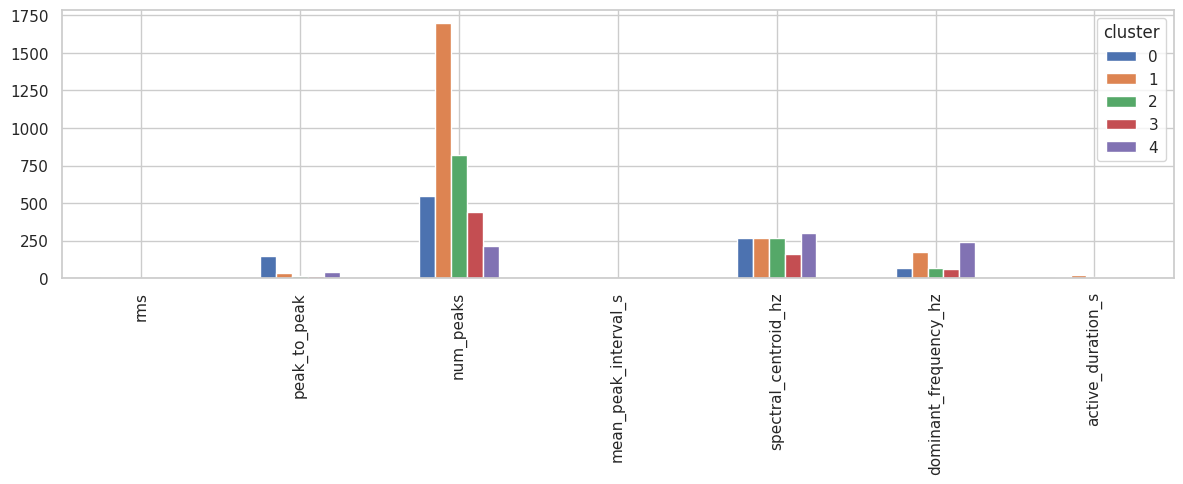

In [12]:
# ============================================================
# 10. Cluster Interpretation
# ============================================================

features_df.groupby("cluster").mean(numeric_only=True)

cluster_means = features_df.groupby("cluster").mean(numeric_only=True)
cluster_means.T.plot(kind="bar", figsize=(12,5))
plt.grid(True)
plt.tight_layout()
plt.show()


In [13]:
# ============================================================
# 11. Train Speed Estimation (Relative)
# ============================================================

features_df["speed_proxy"] = 1.0 / features_df["mean_peak_interval_s"]


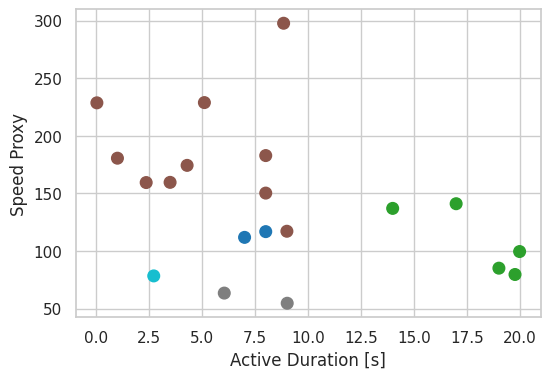

In [14]:
# Speed vs Duration
plt.figure(figsize=(6,4))
plt.scatter(
    features_df["active_duration_s"],
    features_df["speed_proxy"],
    c=features_df["cluster"],
    cmap="tab10",
    s=70
)
plt.xlabel("Active Duration [s]")
plt.ylabel("Speed Proxy")
plt.grid(True)
plt.show()


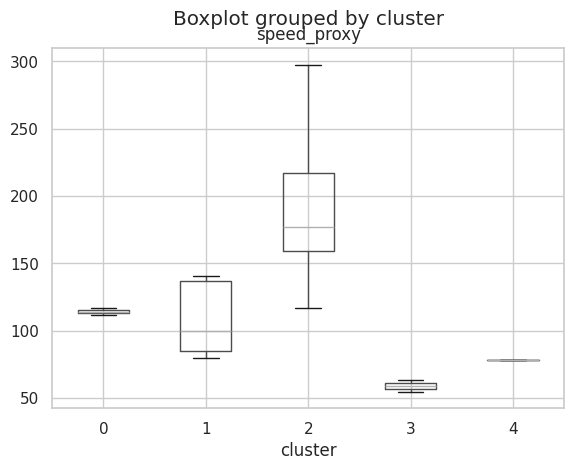

In [15]:
# Speed distribution per cluster
features_df.boxplot(column="speed_proxy", by="cluster")
plt.grid(True)
plt.show()


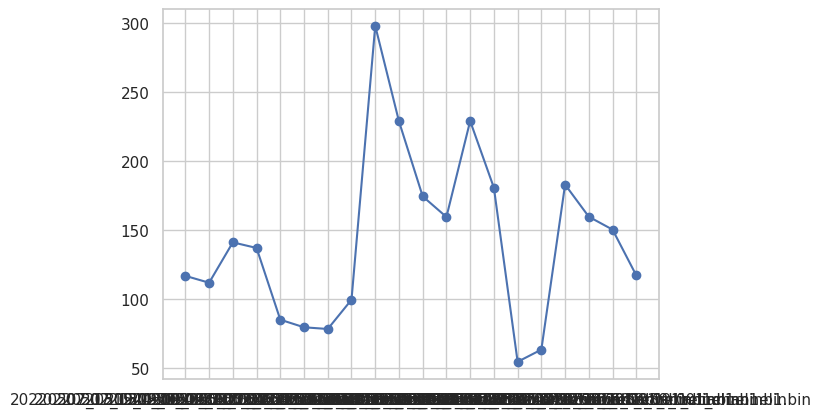

In [16]:
# Speed over time
features_df_sorted = features_df.sort_index()
plt.plot(features_df_sorted["speed_proxy"], marker="o")
plt.grid(True)
plt.show()


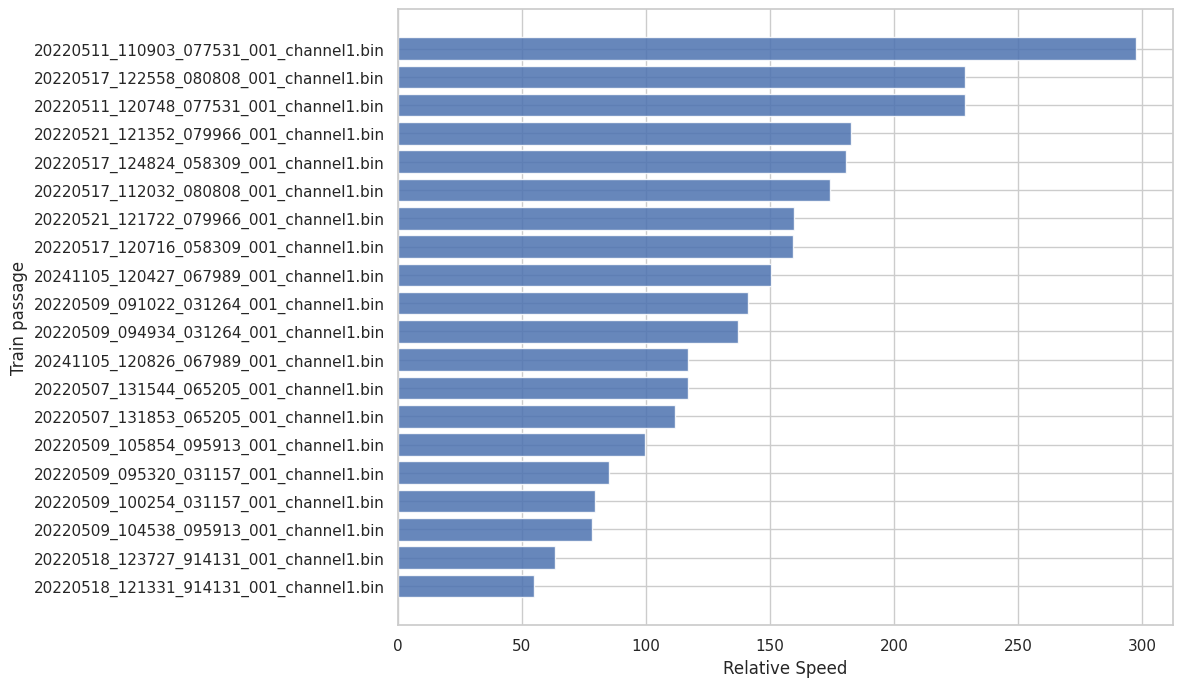

In [17]:
# Horizontal bar charts (speed ranking)
features_df_sorted = features_df.sort_values("speed_proxy")

plt.figure(figsize=(10,8))
plt.barh(features_df_sorted.index, features_df_sorted["speed_proxy"], alpha=0.85)
plt.xlabel("Relative Speed")
plt.ylabel("Train passage")
plt.grid(True)
plt.show()


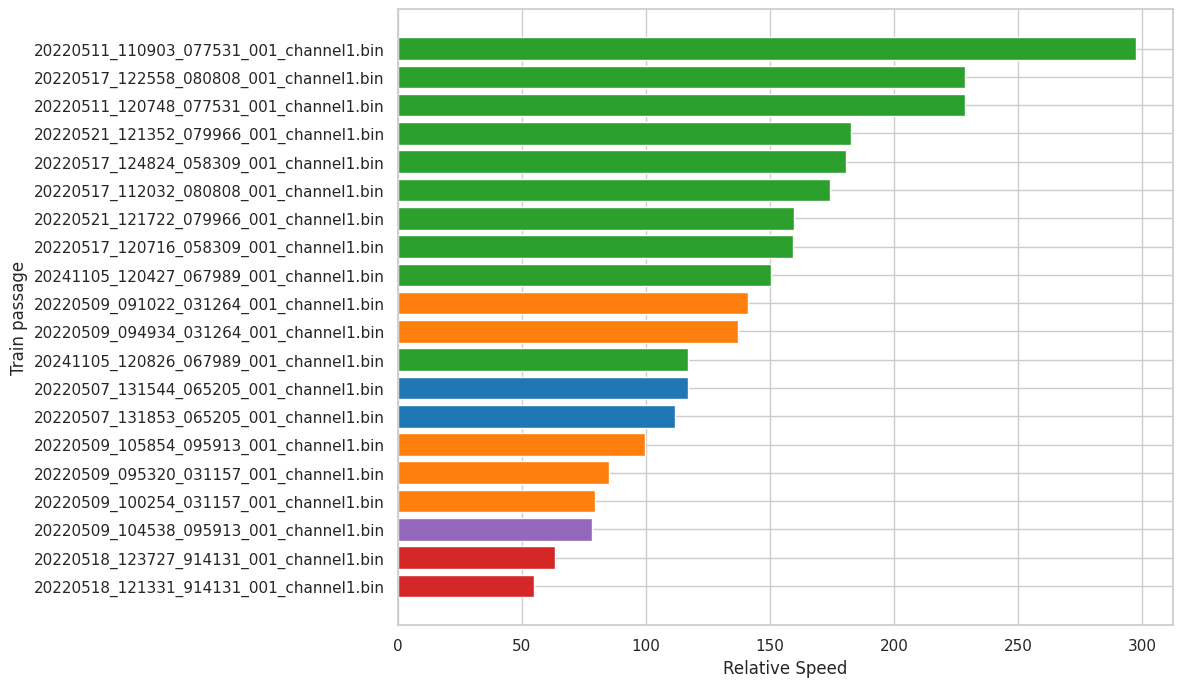

In [18]:
# Horizontal bar chart colored by cluster
palette = sns.color_palette("tab10", features_df_sorted["cluster"].nunique())
colors = features_df_sorted["cluster"].map(dict(enumerate(palette)))

plt.figure(figsize=(10,8))
plt.barh(features_df_sorted.index, features_df_sorted["speed_proxy"], color=colors)
plt.xlabel("Relative Speed")
plt.ylabel("Train passage")
plt.grid(True)
plt.show()


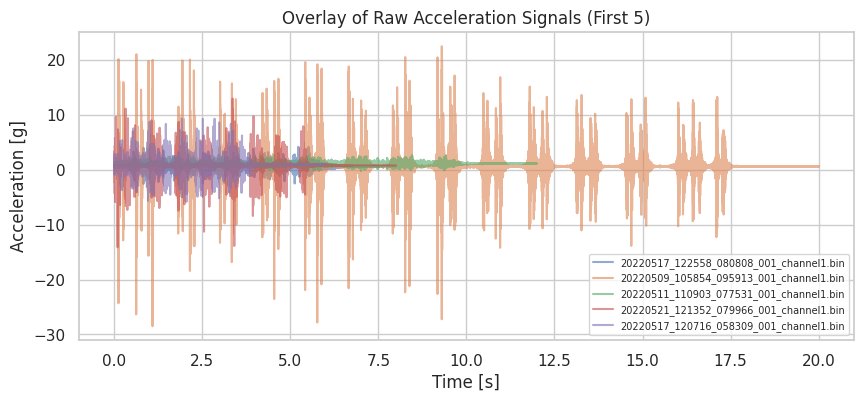

In [19]:
plt.figure(figsize=(10,4))

for fname in list(signals.keys())[:5]:
    x = signals[fname]
    t = np.arange(len(x)) / FS
    plt.plot(t, x, alpha=0.6, label=fname)

plt.xlabel("Time [s]")
plt.ylabel("Acceleration [g]")
plt.title("Overlay of Raw Acceleration Signals (First 5)")
plt.legend(fontsize=7)
plt.grid(True)
plt.show()
